In [70]:
import pandas as pd

df_raw = pd.read_csv("../data/vendas.csv", encoding="latin1")

# 1. Data Profiling (Inspeção dos Dados)

display(df_raw.head())
display(df_raw.tail())
display(df_raw.sample())
print(df_raw.info())
print("Valores duplicados: ", df_raw.duplicated().sum())

print(df_raw["STATE"].unique()) # O resultado mostrou que a coluna não está organizada globalmente.
print(df_raw["TERRITORY"].unique()) # o resultado mostrou que a coluna mistura categorias diferentes de território.
print(df_raw["STATUS"].unique())
print(df_raw["PRODUCTLINE"].unique())

# a função .unique() deve ser utilizada com critério: em colunas categóricas e que podem impactar em análises. O critério evita esforço desnecessário



# A base de dados é internacional, portanto, podem haver diferenças de padronização. Um aprendizado importante com esse projeto: nulos e colunas fora do padrâo não necessariamente implicam erro, o mais importante é manter a base de dados funcional.

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
2818,10350,20,100.00,15,2244.40,12/2/2004 0:00,Shipped,4,12,2004,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Small
2819,10373,29,100.00,1,3978.51,1/31/2005 0:00,Shipped,1,1,2005,...,Torikatu 38,NaN,Oulu,NaN,90110,Finland,EMEA,Koskitalo,Pirkko,Medium
2820,10386,43,100.00,4,5417.57,3/1/2005 0:00,Resolved,1,3,2005,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Medium
2821,10397,34,62.24,1,2116.16,3/28/2005 0:00,Shipped,1,3,2005,...,1 rue Alsace-Lorraine,NaN,Toulouse,NaN,31000,France,EMEA,Roulet,Annette,Small
2822,10414,47,65.52,9,3079.44,5/6/2005 0:00,On Hold,2,5,2005,...,8616 Spinnaker Dr.,NaN,Boston,MA,51003,USA,NaN,Yoshido,Juri,Medium


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
2387,10207,28,94.92,5,2657.76,12/9/2003 0:00,Shipped,4,12,2003,...,6251 Ingle Ln.,NaN,Boston,MA,51003,USA,NaN,Franco,Valarie,Small


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [58]:
# 2. Staging (Tratamento e Preparação dos Dados)

df_staging = df_raw.copy()


# Tipos de Dados
df_staging["ORDERDATE"] = pd.to_datetime(df_staging["ORDERDATE"])


# Padronização

colunas_texto = df_staging.select_dtypes(include="object").columns # Esse comando cria uma coleção com os nomes das colunas dtype object (tipo texto).

for coluna in colunas_texto:
    df_staging[coluna] = df_staging[coluna].str.strip()

df_staging["STATE"] = df_staging["STATE"].str.upper() # Primeiramente, deixei tudo maiúsculo, pois assim fica mais fácil de mapaer com .replace().

dicionario_padrao = {
    'NY': "Nova York",
    'CA': "California",
    'VICTORIA': "Victoria",
    'NJ': "Nova Jersey",
    'CT': "Connecticut",
    'MA': "Massachusetts",
    'PA': "Pennsylvania",
    'NSW': "New South Wales",
    'QUEENSLAND': "Queensland",
    'BC': "British Columbia",
    'TOKYO': "Tokyo",
    'NH': "New Hampshire",
    'QUEBEC': "Quebec",
    'OSAKA': "Osaka",
    'ISLE OF WIGHT': "Isle Of Wight",
    'NV': "Nevada",
}

df_staging["STATE"] = df_staging["STATE"].replace(dicionario_padrao) # Não utilizei .map() porque a .replace() deixa como está quando um valor específico não aparece no dicionário.

# Fiz essa padronização por questões de aprendizado. Porém, é preciso frisar que o ato de padronizar (ou não) depende das necessidades do projeto.


# Duplicados: conferi, no primeiro notebook, que não existem valores duplicados.


# Nulos: a partir da inspeção feita sobre df_row, percebi que os valores nulos existentes não necessariamente indicam erro. Essa determinação só pode ser feita a partir de informações do negócio.


display(df_staging)

display(df_staging.info())


# A coluna endereço não tem um padrão devido ao fato do dataset ser internacional. Novamente, o mais importante é que isso não interfira na capacidade de análise.

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2003-02-24,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,Nova York,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,2003-05-07,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,2003-07-01,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,2003-08-25,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,California,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,2003-10-10,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,California,NaN,USA,NaN,Brown,Julie,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,2004-12-02,Shipped,4,12,2004,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Small
2819,10373,29,100.00,1,3978.51,2005-01-31,Shipped,1,1,2005,...,Torikatu 38,NaN,Oulu,NaN,90110,Finland,EMEA,Koskitalo,Pirkko,Medium
2820,10386,43,100.00,4,5417.57,2005-03-01,Resolved,1,3,2005,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Medium
2821,10397,34,62.24,1,2116.16,2005-03-28,Shipped,1,3,2005,...,1 rue Alsace-Lorraine,NaN,Toulouse,NaN,31000,France,EMEA,Roulet,Annette,Small


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ORDERNUMBER       2823 non-null   int64         
 1   QUANTITYORDERED   2823 non-null   int64         
 2   PRICEEACH         2823 non-null   float64       
 3   ORDERLINENUMBER   2823 non-null   int64         
 4   SALES             2823 non-null   float64       
 5   ORDERDATE         2823 non-null   datetime64[ns]
 6   STATUS            2823 non-null   object        
 7   QTR_ID            2823 non-null   int64         
 8   MONTH_ID          2823 non-null   int64         
 9   YEAR_ID           2823 non-null   int64         
 10  PRODUCTLINE       2823 non-null   object        
 11  MSRP              2823 non-null   int64         
 12  PRODUCTCODE       2823 non-null   object        
 13  CUSTOMERNAME      2823 non-null   object        
 14  PHONE             2823 n

None

In [59]:
# Validação de Consistência

# Vendas Inconsistentes
df_staging["SALES_CALCULADO"] = df_staging["QUANTITYORDERED"] * df_staging["PRICEEACH"]

inconsistentes = df_staging[
   (df_staging["SALES"] - df_staging["SALES_CALCULADO"]).abs() > 0.01
] # A função .abs() pega o valor absoluto. Incosistências só vão ser apontadas caso a diferença seja maior que 1 centavo.

print("Registros com inconsistência em SALES:", len(inconsistentes))

df_staging = df_staging.drop(columns=["SALES_CALCULADO"]) # Excluí SALES_CALCULADO para deixar o df_staging organizado.

# Preços Inválidos
print("PRICEEACH <= 0:", len(df_staging[df_staging["PRICEEACH"] <= 0]))

# Quantidade Inválida
print("QUANTITYORDERED <= 0:", len(df_staging[df_staging["QUANTITYORDERED"] <= 0]))

# Vendas Inválidas
print("SALES <= 0:", len(df_staging[df_staging["SALES"] <= 0]))

# Outras verificações (nulos, datas e categorias) foram realizadas durante a etapa de Data Profiling e não apresentaram inconsistências relevantes.

Registros com inconsistência em SALES: 1304
PRICEEACH <= 0: 0
QUANTITYORDERED <= 0: 0
SALES <= 0: 0


In [60]:
# DataFrame para Análise

df_analise = df_staging.copy()

# A criação de datafremes a cada parte do processo é uma boa prática, pois conserva o dataset.

In [61]:
# Análise - Receita por Produto

analise_produto = df_analise[["PRODUCTLINE", "SALES"]].groupby("PRODUCTLINE").sum()
analise_produto = analise_produto.sort_values(by="SALES", ascending=False)
analise_produto = analise_produto.reset_index() # após o groupby, é uma boa prática alterar a coluna indexada novamente para texto


display(analise_produto)

,PRODUCTLINE,SALES
0,Classic Cars,3919615.66
1,Vintage Cars,1903150.84
2,Motorcycles,1166388.34
3,Trucks and Buses,1127789.84
4,Planes,975003.57
5,Ships,714437.13
6,Trains,226243.47


## Insight — Receita por Linha de Produto

A linha de produto **Classic Cars** concentra a maior parte da receita, apresentando desempenho significativamente superior às demais categorias.

Isso indica uma forte dependência do negócio nessa linha específica, o que pode representar um risco estratégico caso haja queda na demanda.

Além disso, a distribuição desigual da receita sugere baixa diversificação, com categorias como *Trains* e *Ships* tendo pouca participação no faturamento total.

In [62]:
# Análise - Faturamento por País

analise_pais = df_analise[["COUNTRY", "SALES"]].groupby("COUNTRY").sum()
analise_pais = analise_pais.sort_values(by="SALES", ascending=False)
analise_pais = analise_pais.reset_index()

display(analise_pais)

,COUNTRY,SALES
0,USA,3627982.83
1,Spain,1215686.92
2,France,1110916.52
3,Australia,630623.10
4,UK,478880.46
5,Italy,374674.31
6,Finland,329581.91
7,Norway,307463.70
8,Singapore,288488.41
9,Denmark,245637.15


### Insight — Receita por País

A análise de receita por país revela forte concentração nos Estados Unidos, que representam o principal mercado da empresa. Essa dependência indica um risco estratégico, uma vez que o desempenho do negócio está altamente ligado a esse país.

Embora haja presença internacional, não existe um segundo mercado dominante claro, com países como Espanha e França apresentando receitas relevantes, porém significativamente inferiores.

Além disso, observa-se uma longa cauda de países com baixo faturamento, o que pode indicar menor penetração nesses mercados ou oportunidades de expansão internacional.

In [63]:
# Análise - Faturamento por Cliente
analise_cliente_faturamento = df_analise[["CUSTOMERNAME", "SALES"]].groupby("CUSTOMERNAME").sum()
analise_cliente_faturamento = analise_cliente_faturamento.sort_values(by="SALES", ascending=False)
analise_cliente_faturamento = analise_cliente_faturamento.reset_index()

display(analise_cliente_faturamento)

# O dataset não possui ID para cada cliente, então a melhor alternativa foi utilizar a coluna CUSTOMERNAME.

,CUSTOMERNAME,SALES
0,Euro Shopping Channel,912294.11
1,Mini Gifts Distributors Ltd.,654858.06
2,"Australian Collectors, Co.",200995.41
3,Muscle Machine Inc,197736.94
4,La Rochelle Gifts,180124.90
...,...,...
87,Royale Belge,33440.10
88,Microscale Inc.,33144.93
89,Auto-Moto Classics Inc.,26479.26
90,Atelier graphique,24179.96


### Insight — Receita por Cliente

A análise de faturamento por cliente revela uma forte concentração de receita em poucos clientes, com destaque para *Euro Shopping Channel* e *Mini Gifts Distributors Ltd.*, que apresentam valores significativamente superiores aos demais.

Essa concentração indica uma dependência relevante de um pequeno grupo de clientes para a geração de receita, o que pode representar um risco estratégico para o negócio. A perda ou redução de compras desses clientes teria impacto direto no faturamento total.

Além disso, observa-se uma longa cauda de clientes com baixo volume de compras, sugerindo uma base ampla, porém com baixa contribuição individual. Isso pode indicar oportunidades de crescimento nesses clientes menores ou a necessidade de estratégias de segmentação e fidelização.

,ORDERDATE,SALES
0,2003-01,129753.60
1,2003-02,140836.19
2,2003-03,174504.90
3,2003-04,201609.55
4,2003-05,192673.11
5,2003-06,168082.56
6,2003-07,187731.88
7,2003-08,197809.30
8,2003-09,263973.36
9,2003-10,568290.97


Axes(0.125,0.11;0.775x0.77)


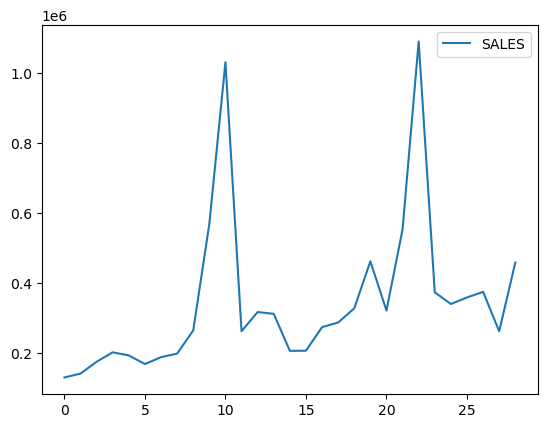

In [66]:
# Análise - Faturamento por Mês

analise_mes = df_analise.groupby(df_staging["ORDERDATE"].dt.to_period("M"))["SALES"].sum() # cria uma Series
analise_mes = analise_mes.reset_index() # utilizar a função .reset_index() faz criar um df
analise_mes = analise_mes.sort_values(by="ORDERDATE", ascending=True)


display(analise_mes)
print(analise_mes.plot()) # A função .plot() cria uma gráfico sobre analise_mes.

### Insight — Receita ao Longo do Tempo

A análise da receita ao longo do tempo revela um padrão claro de sazonalidade, com picos significativos de faturamento nos meses de outubro e, principalmente, novembro, em todos os anos analisados.

O mês de novembro apresenta consistentemente o maior volume de vendas, indicando forte influência de fatores sazonais, como datas comerciais específicas ou aumento da demanda no final do ano.

Após esses picos, observa-se uma queda acentuada em dezembro, sugerindo possível antecipação de compras ou redução da atividade após o período de alta.

Além disso, ao longo dos anos, há indícios de crescimento no faturamento total, embora com variações mensais, o que reforça a importância de estratégias comerciais alinhadas ao calendário para maximizar resultados nos períodos de maior demanda.

In [69]:
# Análise - Distribuição de Status

analise_status = df_analise[["STATUS", "ORDERNUMBER"]].groupby("STATUS").count()
analise_status = analise_status.sort_values(by="ORDERNUMBER", ascending=False)
analise_status = analise_status.reset_index()


display(analise_status)

,STATUS,ORDERNUMBER
0,Shipped,2617
1,Cancelled,60
2,Resolved,47
3,On Hold,44
4,In Process,41
5,Disputed,14


### Insight — Distribuição de Status dos Pedidos

A análise da distribuição de status dos pedidos mostra que a grande maioria está como *Shipped*, indicando uma operação eficiente, com alto volume de pedidos concluídos com sucesso.

Os pedidos cancelados representam uma pequena parcela do total, o que sugere baixa taxa de cancelamento e bom desempenho no processo de vendas e entrega.

Além disso, a presença de pedidos com status como *On Hold*, *In Process* e *Disputed* indica que há uma pequena fração da operação que ainda está em andamento ou enfrenta algum tipo de problema, o que pode representar oportunidades de melhoria nos processos internos.

De forma geral, os dados indicam uma operação saudável, com predominância de pedidos finalizados e baixa incidência de falhas críticas.